# Use this notebook to make training and testing data
This includes:
- LSST + Roman / Euclid data from simulations
- SPS data in multiple bands
- Narrow band data

In [1]:
import os
import random

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split

# LSST + Roman from Cardinal simulation

In [3]:
# grab all pixels:
# Set the path to the directory you want to scan
directory = "/global/cfs/cdirs/lsst/groups/PZ/Cardinal/parquet_files/test_cardinal_gold/"

# Get all folder names (not files) in that directory
folder_names = [name for name in os.listdir(directory) if os.path.isdir(os.path.join(directory, name))]
print(folder_names)

selected_folders = random.sample(folder_names, 5)

print(selected_folders)

['69', '376', '427', '423', '80', '382', '441', '21', '27', '369', '75', '365', '70', '428', '78', '73', '341', '446', '371', '442', '430', '19', '97', '122', '277', '114', '17', '65', '378', '68', '429', '346', '342', '372', '443', '82', '435', '431', '115', '58', '26', '74', '347', '343', '77', '72', '373', '444', '432', '96', '112', '104', '99', '16', '64', '67', '348', '374', '30', '370', '81', '425', '350', '421', '113', '105', '101', '22', '25', '349', '345', '20', '28', '76', '375', '71', '434', '79', '426', '351', '422', '102', '440', '98', '18', '66']
['68', '370', '69', '27', '17']


In [4]:
root = "/global/cfs/cdirs/lsst/groups/PZ/Cardinal/parquet_files/test_cardinal_gold/"
for i, pixel in enumerate(selected_folders):
    fname = root + f"{pixel}/Chinchilla-3-triofile.pq"
    fin = pd.read_parquet(fname)
    # select 0.5% from each folder
    if i == 0:
        sample_sub = fin.sample(frac=0.005)
    if i > 0:
        df = fin.sample(frac=0.005)
        sample_sub = pd.concat([sample_sub, df], ignore_index=True)

In [5]:
sample_sub.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 222043 entries, 0 to 222042
Data columns (total 43 columns):
 #   Column                      Non-Null Count   Dtype  
---  ------                      --------------   -----  
 0   galaxy_id                   222043 non-null  float64
 1   ra                          222043 non-null  float64
 2   dec                         222043 non-null  float64
 3   sedid                       222043 non-null  int64  
 4   size                        222043 non-null  float64
 5   Ellipticity_1               222043 non-null  float64
 6   Ellipticity_2               222043 non-null  float64
 7   mag_u_lsst                  222043 non-null  float64
 8   mag_g_lsst                  222043 non-null  float64
 9   mag_r_lsst                  222043 non-null  float64
 10  mag_i_lsst                  222043 non-null  float64
 11  mag_z_lsst                  222043 non-null  float64
 12  mag_y_lsst                  222043 non-null  float64
 13  Roman_Y106    

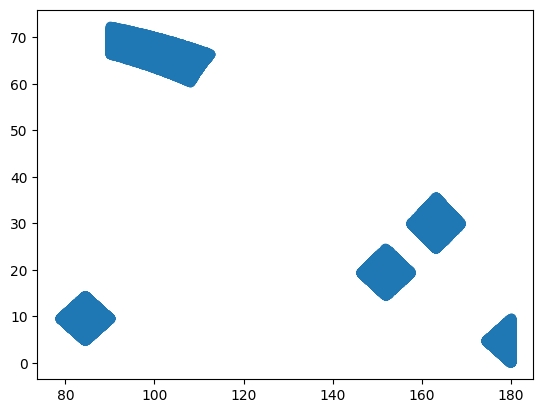

In [6]:
plt.scatter(sample_sub["ra"], sample_sub["dec"])

In [10]:
# now split the sample in train and test:
train_df, test_df = train_test_split(sample_sub, test_size=0.5, random_state=42)
train_df = train_df.reset_index(drop=True)
test_df = test_df.reset_index(drop=True)

In [11]:
train_df

,galaxy_id,ra,dec,sedid,size,Ellipticity_1,Ellipticity_2,mag_u_lsst,mag_g_lsst,mag_r_lsst,...,mag_h_euclid_nisp,Roman_obs_Y106,Roman_obs_J129,Roman_obs_H158,Roman_obs_F184,Roman_obs_K213,totalHalfLightRadiusArcsec,TotalEllipticity,major,minor
0,1.220097e+11,97.260439,68.043196,503559,0.198793,0.098882,-0.022992,27.018232,26.381393,25.686718,...,23.708456,24.118835,23.906360,23.726416,23.685627,23.601253,0.198793,0.101519,0.623915,0.063340
1,3.700073e+11,83.439749,6.180214,461969,0.384151,-0.065180,0.193945,25.649228,25.037714,24.224175,...,22.337273,22.764165,22.564794,22.429080,22.296058,22.253960,0.384151,0.204604,0.849267,0.173764
2,6.900164e+10,150.257497,16.917345,124896,5.455728,-0.061798,-0.083789,24.701485,23.870313,23.574301,...,23.098788,23.248204,23.204037,23.147173,23.069383,23.207153,5.455728,0.104113,16.908299,1.760376
3,1.220017e+11,104.197758,66.935444,451850,0.624914,-0.278284,0.022957,25.795657,23.610269,22.049639,...,20.180596,20.789929,20.461436,20.239232,20.154328,20.021365,0.624914,0.279229,1.182606,0.330218
4,3.700067e+11,85.509885,12.846661,388974,0.185924,-0.091106,-0.143487,28.074967,27.470702,26.477650,...,23.962126,24.453671,24.154959,24.088117,23.910551,23.801860,0.185924,0.169967,0.450975,0.076651
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
111016,8.100192e+10,158.156635,29.370453,42776,0.913584,0.060152,-0.039980,26.790744,26.078900,25.527365,...,24.806909,25.129399,24.946535,24.861618,24.795616,24.656220,0.913584,0.072227,3.399379,0.245526
111017,8.100167e+10,163.449143,28.244764,351524,0.898896,-0.200928,0.025972,25.542989,25.034965,24.602366,...,23.895415,24.183175,24.037121,23.948517,23.882501,23.761752,0.898896,0.202600,1.997056,0.404603
111018,1.220028e+11,106.069863,67.069834,384363,0.353408,0.273163,-0.350065,23.791406,22.984954,21.893989,...,20.280104,20.913543,20.653592,20.381360,20.240161,20.134348,0.353408,0.444031,0.530359,0.235496
111019,1.220091e+11,106.998446,61.575013,520025,0.198628,-0.045093,0.132784,24.307850,24.192531,23.959829,...,21.148296,22.013424,21.586212,21.276976,21.091618,20.869815,0.198628,0.140232,0.530418,0.074382


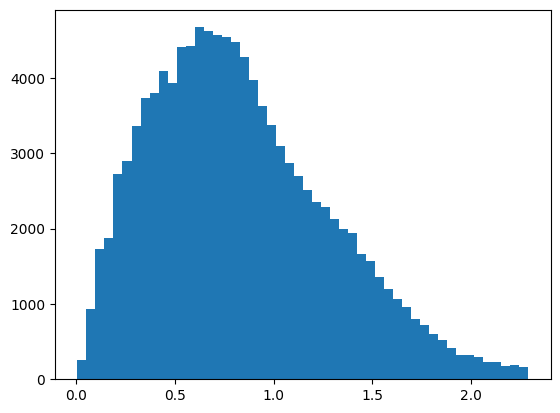

In [12]:
cc = plt.hist(train_df["redshift"], bins=50)

In [16]:
# save the catalogues:
saveroot = "/pscratch/sd/q/qhang/cnnpz/cardinal/"
train_df.to_parquet(saveroot + "train_100k.parquet", index=False)
test_df.to_parquet(saveroot + "test_100k.parquet", index=False)

### a larger subsample for Y1 degradation

In [4]:
root = "/global/cfs/cdirs/lsst/groups/PZ/Cardinal/parquet_files/test_cardinal_gold/"
for i, pixel in enumerate(selected_folders):
    fname = root + f"{pixel}/Chinchilla-3-triofile.pq"
    fin = pd.read_parquet(fname)
    # select 0.5% from each folder
    if i == 0:
        sample_sub_large = fin.sample(frac=0.025)
    if i > 0:
        df = fin.sample(frac=0.025)
        sample_sub_large = pd.concat([sample_sub_large, df], ignore_index=True)

In [5]:
sample_sub_large.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1236108 entries, 0 to 1236107
Data columns (total 43 columns):
 #   Column                      Non-Null Count    Dtype  
---  ------                      --------------    -----  
 0   galaxy_id                   1236108 non-null  float64
 1   ra                          1236108 non-null  float64
 2   dec                         1236108 non-null  float64
 3   sedid                       1236108 non-null  int64  
 4   size                        1236108 non-null  float64
 5   Ellipticity_1               1236108 non-null  float64
 6   Ellipticity_2               1236108 non-null  float64
 7   mag_u_lsst                  1236108 non-null  float64
 8   mag_g_lsst                  1236108 non-null  float64
 9   mag_r_lsst                  1236108 non-null  float64
 10  mag_i_lsst                  1236108 non-null  float64
 11  mag_z_lsst                  1236108 non-null  float64
 12  mag_y_lsst                  1236108 non-null  float64
 1

In [7]:
# now split the sample in train and test:
train_df, test_df = train_test_split(sample_sub_large, test_size=0.5, random_state=42)
train_df = train_df.reset_index(drop=True)
test_df = test_df.reset_index(drop=True)

In [9]:
# save the catalogues:
saveroot = "/pscratch/sd/q/qhang/cnnpz/cardinal/"
train_df.to_parquet(saveroot + "train_500k.parquet", index=False)
test_df.to_parquet(saveroot + "test_500k.parquet", index=False)

# add noise - LSST Y1 and Y10, Roman medium, Euclid wide

In [61]:
import h5py
from photerr import EuclidWideErrorModel, LsstErrorModelV2, RomanMediumErrorModel

In [62]:
renameDict_lsst = {
    "u": "mag_u_lsst",
    "g": "mag_g_lsst",
    "r": "mag_r_lsst",
    "i": "mag_i_lsst",
    "z": "mag_z_lsst",
    "y": "mag_y_lsst",
}
renameDict_euclid = {
    # "VIS":,
    "Y": "mag_y_euclid_nisp",
    "J": "mag_j_euclid_nisp",
    "H": "mag_h_euclid_nisp",
}
renameDict_roman = {
    "Y": "Roman_obs_Y106",
    "J": "Roman_obs_J129",
    "H": "Roman_obs_H158",
}

In [5]:
# load in the train and test files:
saveroot = "/pscratch/sd/q/qhang/cnnpz/cardinal/"
fname = saveroot + "train_100k.parquet"
training_data = pd.read_parquet(fname)
# training_data.info()

saveroot = "/pscratch/sd/q/qhang/cnnpz/cardinal/"
fname = saveroot + "test_100k.parquet"
test_data = pd.read_parquet(fname)
# test_data.info()

In [4]:
# load in the train and test files:
saveroot = "/pscratch/sd/q/qhang/cnnpz/cardinal/"
fname = saveroot + "train_500k.parquet"
training_data_large = pd.read_parquet(fname)
# training_data.info()

saveroot = "/pscratch/sd/q/qhang/cnnpz/cardinal/"
fname = saveroot + "test_500k.parquet"
test_data_large = pd.read_parquet(fname)
# test_data.info()

In [63]:
em_lsst_y1 = LsstErrorModelV2(renameDict=renameDict_lsst, nYrObs=1, extendedType="gaap", aMin=1.5)
em_lsst_y10 = LsstErrorModelV2(renameDict=renameDict_lsst, nYrObs=10, extendedType="gaap", aMin=1.5)
em_euclid = EuclidWideErrorModel(renameDict=renameDict_euclid)
em_roman = RomanMediumErrorModel(renameDict=renameDict_roman)

In [7]:
# Y1
# build noisy training data
cols1 = list(renameDict_lsst.values())
cols1.append("major")
cols1.append("minor")
training_lsst_error_y1 = em_lsst_y1(training_data_large[cols1])

cols2 = list(renameDict_euclid.values())
training_euclid_error = em_euclid(training_data_large[cols2])

cols3 = list(renameDict_roman.values())
training_roman_error = em_roman(training_data_large[cols3])

# combine the data
training_drop = training_data_large.drop(columns=cols1 + cols2 + cols3)
training_error_y1 = pd.concat(
    [training_drop, training_lsst_error_y1, training_euclid_error, training_roman_error], axis=1
)

In [23]:
# Y10
cols1 = list(renameDict_lsst.values())
cols1.append("major")
cols1.append("minor")
training_lsst_error_y10 = em_lsst_y10(training_data[cols1])

cols2 = list(renameDict_euclid.values())
training_euclid_error = em_euclid(training_data[cols2])

cols3 = list(renameDict_roman.values())
training_roman_error = em_roman(training_data[cols3])

# combine the data
training_drop = training_data.drop(columns=cols1 + cols2 + cols3)
training_error_y10 = pd.concat(
    [training_drop, training_lsst_error_y10, training_euclid_error, training_roman_error], axis=1
)

In [8]:
training_error_y1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 618054 entries, 0 to 618053
Data columns (total 55 columns):
 #   Column                      Non-Null Count   Dtype  
---  ------                      --------------   -----  
 0   galaxy_id                   618054 non-null  float64
 1   ra                          618054 non-null  float64
 2   dec                         618054 non-null  float64
 3   sedid                       618054 non-null  int64  
 4   size                        618054 non-null  float64
 5   Ellipticity_1               618054 non-null  float64
 6   Ellipticity_2               618054 non-null  float64
 7   Roman_Y106                  618054 non-null  float64
 8   Roman_J129                  618054 non-null  float64
 9   Roman_H158                  618054 non-null  float64
 10  Roman_F184                  618054 non-null  float64
 11  Roman_K213                  618054 non-null  float64
 12  WISE_W1                     618054 non-null  float64
 13  WISE_W2       

In [9]:
# count i-band detections for Y1 and Y10, with i < 23 and i < 25.4
print("Y1")
count1 = sum(training_error_y1["mag_i_lsst"] < 23)
count2 = sum(training_error_y1["mag_i_lsst"] < 25.4)
print("i<23", count1, "i<25.4", count2)

print("Y10")
count1 = sum(training_error_y10["mag_i_lsst"] < 23)
count2 = sum(training_error_y10["mag_i_lsst"] < 25.4)
print("i<23", count1, "i<25.4", count2)

Y1
i<23 107189 i<25.4 548856
Y10


NameError: name 'training_error_y10' is not defined

In [10]:
# Y1 test set:

# build noisy test data
cols1 = list(renameDict_lsst.values())
cols1.append("major")
cols1.append("minor")
test_lsst_error_y1 = em_lsst_y1(test_data_large[cols1])

cols2 = list(renameDict_euclid.values())
test_euclid_error = em_euclid(test_data_large[cols2])

cols3 = list(renameDict_roman.values())
test_roman_error = em_roman(test_data_large[cols3])

# combine the data
test_drop = test_data_large.drop(columns=cols1 + cols2 + cols3)
test_error_y1 = pd.concat([test_drop, test_lsst_error_y1, test_euclid_error, test_roman_error], axis=1)

In [31]:
# do the same for the test set:
# build noisy test data
cols1 = list(renameDict_lsst.values())
cols1.append("major")
cols1.append("minor")
test_lsst_error_y10 = em_lsst_y10(test_data[cols1])

cols2 = list(renameDict_euclid.values())
test_euclid_error = em_euclid(test_data[cols2])

cols3 = list(renameDict_roman.values())
test_roman_error = em_roman(test_data[cols3])

# combine the data
test_drop = test_data.drop(columns=cols1 + cols2 + cols3)
test_error_y10 = pd.concat([test_drop, test_lsst_error_y10, test_euclid_error, test_roman_error], axis=1)

In [11]:
# count i-band detections for Y1 and Y10, with i < 23 and i < 25.3
print("Y1")
count1 = sum(test_error_y1["mag_i_lsst"] < 23)
count2 = sum(test_error_y1["mag_i_lsst"] < 25.4)
print("i<23", count1, "i<25.4", count2)

print("Y10")
count1 = sum(test_error_y10["mag_i_lsst"] < 23)
count2 = sum(test_error_y10["mag_i_lsst"] < 25.4)
print("i<23", count1, "i<25.4", count2)

Y1
i<23 107506 i<25.4 548705
Y10


NameError: name 'test_error_y10' is not defined

In [36]:
# save the y10 sample with the magnitude cut:
# save the catalogues:
saveroot = "/pscratch/sd/q/qhang/cnnpz/cardinal/"

save_train = training_error_y10[training_error_y10["mag_i_lsst"] < 25.4]
save_test = test_error_y10[test_error_y10["mag_i_lsst"] < 25.4]

save_train.to_parquet(saveroot + "train_100k_noisy_y10_i25.4.parquet", index=False)
save_test.to_parquet(saveroot + "test_100k_noisy_y10_i25.4.parquet", index=False)

In [12]:
# save the y10 sample with the magnitude cut:
# save the catalogues:
saveroot = "/pscratch/sd/q/qhang/cnnpz/cardinal/"

save_train = training_error_y1[training_error_y1["mag_i_lsst"] < 23]
save_test = test_error_y1[test_error_y1["mag_i_lsst"] < 23]

save_train.to_parquet(saveroot + "train_100k_noisy_y1_i23.parquet", index=False)
save_test.to_parquet(saveroot + "test_100k_noisy_y1_i23.parquet", index=False)

## noisify the pop-cosmos data in the same way

In [39]:
# let's also load pre-training data:
f = h5py.File("/pscratch/sd/q/qhang/pop-cosmos-data/mock_catalog_Ch1_26.h5", "r")

# Load the full arrays into memory ONCE (this is the only disk read)
fluxes_rubin = f["fluxes_rubin"][:]  # numpy array, all in RAM
fluxes_roman = f["fluxes_roman"][:]
sps_params = f["sps_parameters"][:]

pre_training_popcosmos = {}
# collect ugrizy
# first, select samples with i < 25.5
ind = -2.5 * np.log10(fluxes_rubin[:, 3]) < 25.5
for i, band in enumerate("ugrizy"):
    pre_training_popcosmos[f"mag_{band}_lsst"] = -2.5 * np.log10(fluxes_rubin[ind, i])

for i, band in zip([2, 3, 5], "YJH"):
    pre_training_popcosmos[f"mag_{band}_roman"] = -2.5 * np.log10(fluxes_roman[ind, i])

pre_training_popcosmos["redshift"] = sps_params[ind, -1]

pre_training_popcosmos = pd.DataFrame(pre_training_popcosmos)
# compare with the test set to see if we cover the full feature space
print(len(pre_training_popcosmos))

1020300


In [42]:
renameDict_lsst = {
    "u": "mag_u_lsst",
    "g": "mag_g_lsst",
    "r": "mag_r_lsst",
    "i": "mag_i_lsst",
    "z": "mag_z_lsst",
    "y": "mag_y_lsst",
}
renameDict_roman = {
    "Y": "mag_Y_roman",
    "J": "mag_J_roman",
    "H": "mag_H_roman",
}

In [46]:
# let's degrade this to lsst y10 and y1:
em_lsst_y1 = LsstErrorModelV2(renameDict=renameDict_lsst, nYrObs=1, extendedType="point")
em_lsst_y10 = LsstErrorModelV2(renameDict=renameDict_lsst, nYrObs=10, extendedType="point")
em_roman = RomanMediumErrorModel(renameDict=renameDict_roman)

cols1 = list(renameDict_lsst.values())
pretraining_lsst_error_y1 = em_lsst_y1(pre_training_popcosmos[cols1])
pretraining_lsst_error_y10 = em_lsst_y10(pre_training_popcosmos[cols1])

cols3 = list(renameDict_roman.values())
pretraining_roman_error = em_roman(pre_training_popcosmos[cols3])

# combine the data
pretraining_drop = pre_training_popcosmos.drop(columns=cols1 + cols3)
pretraining_error_y1 = pd.concat([pretraining_drop, pretraining_lsst_error_y1, pretraining_roman_error], axis=1)
pretraining_error_y10 = pd.concat([pretraining_drop, pretraining_lsst_error_y10, pretraining_roman_error], axis=1)

In [47]:
pretraining_error_y1

,redshift,mag_u_lsst,mag_u_lsst_err,mag_g_lsst,mag_g_lsst_err,mag_r_lsst,mag_r_lsst_err,mag_i_lsst,mag_i_lsst_err,mag_z_lsst,mag_z_lsst_err,mag_y_lsst,mag_y_lsst_err,mag_Y_roman,mag_Y_roman_err,mag_J_roman,mag_J_roman_err,mag_H_roman,mag_H_roman_err
0,1.747559,25.264606,0.382390,25.615621,0.189784,25.174528,0.114835,25.628074,0.268843,24.658659,0.221336,24.902832,0.549583,24.530999,0.035189,24.187795,0.028372,24.264459,0.030359
1,1.029517,25.064571,0.327038,25.333414,0.149416,23.235780,0.021208,22.097369,0.013290,21.158183,0.011478,20.717973,0.016459,20.482382,0.005071,20.089776,0.005042,19.704943,0.005021
2,0.698835,25.106437,0.338018,24.415813,0.067405,24.019227,0.041665,23.674354,0.050046,23.693327,0.096949,23.855293,0.243592,23.379861,0.013170,23.587319,0.016903,23.553712,0.016436
3,1.504613,24.773080,0.258851,25.070136,0.119171,25.177060,0.115088,25.532049,0.248544,24.981702,0.288394,25.367338,0.758220,24.730034,0.042008,24.539155,0.038742,24.445313,0.035639
4,0.549510,24.508015,0.208191,23.992852,0.046567,23.178245,0.020216,22.693673,0.021402,22.573097,0.036255,22.406719,0.070259,22.250808,0.006607,22.098021,0.006475,21.951987,0.006159
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1020295,1.194713,24.597625,0.224208,25.340455,0.150317,25.367563,0.135691,25.419783,0.226557,24.974369,0.286691,24.241293,0.332727,24.344474,0.029827,24.379554,0.033617,24.309972,0.031606
1020296,0.456388,26.897194,1.152928,26.222881,0.312373,24.206528,0.049122,23.383351,0.038754,23.204917,0.063155,22.816087,0.100574,22.717914,0.008309,22.399714,0.007381,22.161496,0.006635
1020297,0.256623,inf,inf,25.664196,0.197677,25.306785,0.128764,25.286131,0.202683,25.522519,0.440390,24.928485,0.559835,25.128402,0.059913,25.075878,0.062498,24.939217,0.055338
1020298,2.393938,27.909844,1.909423,25.978067,0.256323,24.898407,0.090267,24.378754,0.092978,24.086147,0.136305,23.414763,0.168491,23.231424,0.011750,22.192674,0.006719,21.246673,0.005341


In [48]:
pretraining_error_y10

,redshift,mag_u_lsst,mag_u_lsst_err,mag_g_lsst,mag_g_lsst_err,mag_r_lsst,mag_r_lsst_err,mag_i_lsst,mag_i_lsst_err,mag_z_lsst,mag_z_lsst_err,mag_y_lsst,mag_y_lsst_err,mag_Y_roman,mag_Y_roman_err,mag_J_roman,mag_J_roman_err,mag_H_roman,mag_H_roman_err
0,1.747559,25.924153,0.237555,25.404004,0.052930,25.332679,0.043635,25.239137,0.065634,25.274828,0.128882,25.345298,0.295776,24.530999,0.035189,24.187795,0.028372,24.264459,0.030359
1,1.029517,26.371069,0.340825,25.288123,0.047767,23.297628,0.008542,22.111419,0.006374,21.143031,0.005953,20.703673,0.007012,20.482382,0.005071,20.089776,0.005042,19.704943,0.005021
2,0.698835,24.513171,0.070715,24.343442,0.020940,24.021575,0.014182,23.676824,0.016784,23.531911,0.027727,23.570447,0.064690,23.379861,0.013170,23.587319,0.016903,23.553712,0.016436
3,1.504613,25.387993,0.151328,25.248164,0.046106,25.200660,0.038816,25.077540,0.056870,25.155637,0.116211,24.759560,0.182183,24.730034,0.042008,24.539155,0.038742,24.445313,0.035639
4,0.549510,24.245537,0.055879,23.941189,0.015031,23.179036,0.007989,22.696412,0.008307,22.559784,0.012393,22.350157,0.022090,22.250808,0.006607,22.098021,0.006475,21.951987,0.006159
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1020295,1.194713,25.763465,0.207890,25.633775,0.064871,25.490282,0.050187,25.357161,0.072864,24.678794,0.076471,24.497817,0.145714,24.344474,0.029827,24.379554,0.033617,24.309972,0.031606
1020296,0.456388,27.138109,0.605560,25.589964,0.062405,24.167069,0.015939,23.481079,0.014326,23.189604,0.020633,22.864137,0.034585,22.717914,0.008309,22.399714,0.007381,22.161496,0.006635
1020297,0.256623,26.763612,0.461077,25.836207,0.077573,25.552366,0.053032,25.254544,0.066537,24.978332,0.099538,25.322450,0.290376,25.128402,0.059913,25.075878,0.062498,24.939217,0.055338
1020298,2.393938,26.306432,0.323819,25.474345,0.056332,24.804289,0.027380,24.482726,0.033564,24.121763,0.046669,23.632067,0.068319,23.231424,0.011750,22.192674,0.006719,21.246673,0.005341


In [49]:
# save these files:
fname = "/pscratch/sd/q/qhang/pop-cosmos-data/mock_catalog_Ch1_26.degrade_lsst_y1.parquet"
pretraining_error_y1.to_parquet(fname, index=False)

fname = "/pscratch/sd/q/qhang/pop-cosmos-data/mock_catalog_Ch1_26.degrade_lsst_y10.parquet"
pretraining_error_y10.to_parquet(fname, index=False)

# sub-select in colour space (tasket 2)

- options:
    1. take the same selection by running through the cardinal spec degrader -> we will get pretty much the same sample
    3. match colour redshift features using a SOM (can say things like we match to the distribution)

In [2]:
# run these selectors on cardinal
from rail.creation.degraders.spectroscopic_selections import (
    SpecSelection_DEEP2_LSST,
    SpecSelection_DESI_BGS,
    SpecSelection_DESI_ELG_LOP,
    SpecSelection_DESI_LRG,
    SpecSelection_VVDSf02,
    SpecSelection_zCOSMOS,
)

In [65]:
# load the large training sample
saveroot = "/pscratch/sd/q/qhang/cnnpz/cardinal/"
raw = pd.read_parquet(saveroot + "train_500k.parquet")

# degrade to Y10 depth
cols1 = list(renameDict_lsst.values())
cols1.append("major")
cols1.append("minor")
training_lsst_error_y10 = em_lsst_y10(raw[cols1])

cols2 = list(renameDict_euclid.values())
training_euclid_error = em_euclid(raw[cols2])

cols3 = list(renameDict_roman.values())
training_roman_error = em_roman(raw[cols3])

# combine the data
training_drop = raw.drop(columns=cols1 + cols2 + cols3)
training_error_y10 = pd.concat(
    [training_drop, training_lsst_error_y10, training_euclid_error, training_roman_error], axis=1
)

save_train = training_error_y10[training_error_y10["mag_i_lsst"] < 25.4]

print(len(save_train))

575502


In [66]:
# load in the degraded training dataset:
saveroot = "/pscratch/sd/q/qhang/cnnpz/cardinal/"
train_y10 = pd.read_parquet(saveroot + "train_100k_noisy_y10_i25.4.parquet")
train_y1 = pd.read_parquet(saveroot + "train_100k_noisy_y1_i23.parquet")

In [67]:
colnames = {
    "redshift": "redshift",
    "u": "mag_u_lsst",
    "g": "mag_g_lsst",
    "r": "mag_r_lsst",
    "i": "mag_i_lsst",
    "z": "mag_z_lsst",
    "y": "mag_y_lsst",
    "W1": "WISE_W1",
    "W2": "WISE_W2",
}

In [68]:
# deep2_lsst:
deep2lsst_selector = SpecSelection_DEEP2_LSST.make_stage(downsample=False, colnames=colnames)

deep2_lsst_data = deep2lsst_selector(save_train)
print(len(deep2_lsst_data.data))

desibgs_selector = SpecSelection_DESI_BGS.make_stage(downsample=False, colnames=colnames)

desibgs_data = desibgs_selector(save_train)
print(len(desibgs_data.data))

desilrg_selector = SpecSelection_DESI_LRG.make_stage(downsample=False, colnames=colnames)

desilrg_data = desilrg_selector(save_train)
print(len(desilrg_data.data))

desielg_selector = SpecSelection_DESI_ELG_LOP.make_stage(downsample=False, colnames=colnames)

desielg_data = desielg_selector(save_train)
print(len(desielg_data.data))

vvds_selector = SpecSelection_VVDSf02.make_stage(downsample=False, colnames=colnames)

vvds_data = vvds_selector(save_train)
print(len(vvds_data.data))

zcosmos_selecter = SpecSelection_zCOSMOS.make_stage(downsample=False, colnames=colnames)
zcosmos_data = zcosmos_selecter(save_train)
print(len(zcosmos_data.data))

Inserting handle into data store.  input: None, SpecSelection_DEEP2_LSST
Inserting handle into data store.  output: inprogress_output.pq, SpecSelection_DEEP2_LSST
44566
Inserting handle into data store.  input: None, SpecSelection_DESI_BGS
Applying the selection for DESI BGS (r < 19.5)...
Inserting handle into data store.  output: inprogress_output.pq, SpecSelection_DESI_BGS
2320
Inserting handle into data store.  input: None, SpecSelection_DESI_LRG
Applying the selection for DESI LRG (simplified cuts)...
Inserting handle into data store.  output: inprogress_output.pq, SpecSelection_DESI_LRG
7820
Inserting handle into data store.  input: None, SpecSelection_DESI_ELG_LOP
Applying the selection for DESI ELG_LOP...
Inserting handle into data store.  output: inprogress_output.pq, SpecSelection_DESI_ELG_LOP
2839
Inserting handle into data store.  input: None, SpecSelection_VVDSf02
Inserting handle into data store.  output: inprogress_output.pq, SpecSelection_VVDSf02
143485
Inserting handle 

In [73]:
# merge:
from functools import reduce

subs = [deep2_lsst_data, desibgs_data, desilrg_data, desielg_data, vvds_data, zcosmos_data]
idx = reduce(lambda a, b: a.union(b), [s.data.index for s in subs])
merged_specsel_y10 = save_train.loc[idx]
# downsample to 100k
merged_specsel_y10 = merged_specsel_y10.sample(n=100000, random_state=42)

Text(0.5, 0, 'redshift')

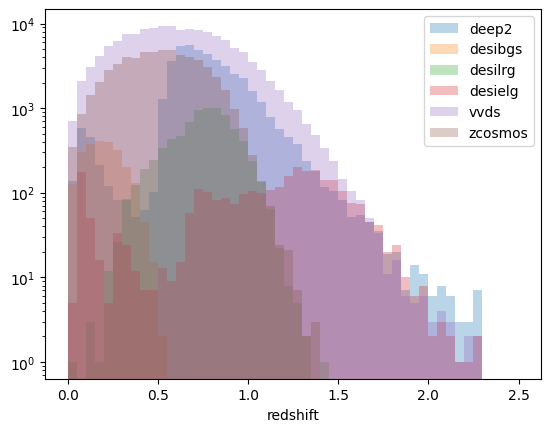

In [70]:
# plot their redshift distribution:
for dataset, tag in zip(
    (deep2_lsst_data, desibgs_data, desilrg_data, desielg_data, vvds_data, zcosmos_data),
    ("deep2", "desibgs", "desilrg", "desielg", "vvds", "zcosmos"),
):
    red = dataset.data["redshift"]
    cc = plt.hist(red, bins=50, range=[0, 2.5], alpha=0.3, label=tag)
plt.yscale("log")
plt.legend()
plt.xlabel("redshift")

100000


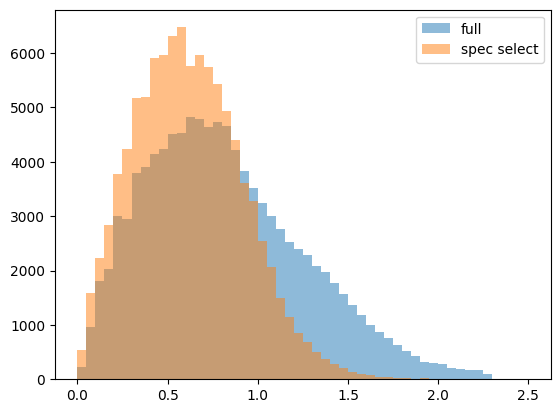

In [74]:
red = train_y10["redshift"]
cc = plt.hist(red, bins=50, range=[0, 2.5], label="full", alpha=0.5)

red = merged_specsel_y10["redshift"]
cc = plt.hist(red, bins=50, range=[0, 2.5], label="spec select", alpha=0.5)
plt.legend()
print(len(red))
# plt.yscale('log')

In [75]:
# let's save this for 10 - year
saveroot = "/pscratch/sd/q/qhang/cnnpz/cardinal/"
fname = saveroot + "train_100k_noisy_y10_i25.4.SpecSelect.parquet"
merged_specsel_y10.to_parquet(fname)

In [46]:
# deep2_lsst:
deep2lsst_selector = SpecSelection_DEEP2_LSST.make_stage(downsample=False, colnames=colnames)

deep2_lsst_data = deep2lsst_selector(train_y1)
print(len(deep2_lsst_data.data))

desibgs_selector = SpecSelection_DESI_BGS.make_stage(downsample=False, colnames=colnames)

desibgs_data = desibgs_selector(train_y1)
print(len(desibgs_data.data))

desilrg_selector = SpecSelection_DESI_LRG.make_stage(downsample=False, colnames=colnames)

desilrg_data = desilrg_selector(train_y1)
print(len(desilrg_data.data))

desielg_selector = SpecSelection_DESI_ELG_LOP.make_stage(downsample=False, colnames=colnames)

desielg_data = desielg_selector(train_y1)
print(len(desielg_data.data))

vvds_selector = SpecSelection_VVDSf02.make_stage(downsample=False, colnames=colnames)

vvds_data = vvds_selector(train_y1)
print(len(vvds_data.data))

zcosmos_selecter = SpecSelection_zCOSMOS.make_stage(downsample=False, colnames=colnames)
zcosmos_data = zcosmos_selecter(train_y1)
print(len(zcosmos_data.data))

Inserting handle into data store.  input: None, SpecSelection_DEEP2_LSST
Inserting handle into data store.  output: inprogress_output.pq, SpecSelection_DEEP2_LSST
33819
Inserting handle into data store.  input: None, SpecSelection_DESI_BGS
Applying the selection for DESI BGS (r < 19.5)...
Inserting handle into data store.  output: inprogress_output.pq, SpecSelection_DESI_BGS
2327
Inserting handle into data store.  input: None, SpecSelection_DESI_LRG
Applying the selection for DESI LRG (simplified cuts)...
Inserting handle into data store.  output: inprogress_output.pq, SpecSelection_DESI_LRG
6911
Inserting handle into data store.  input: None, SpecSelection_DESI_ELG_LOP
Applying the selection for DESI ELG_LOP...
Inserting handle into data store.  output: inprogress_output.pq, SpecSelection_DESI_ELG_LOP
883
Inserting handle into data store.  input: None, SpecSelection_VVDSf02
Inserting handle into data store.  output: inprogress_output.pq, SpecSelection_VVDSf02
86929
Inserting handle in

In [49]:
# merge:
from functools import reduce

subs = [deep2_lsst_data, desibgs_data, desilrg_data, desielg_data, vvds_data, zcosmos_data]
idx = reduce(lambda a, b: a.union(b), [s.data.index for s in subs])
merged_specsel_y1 = train_y1.loc[idx]

90616


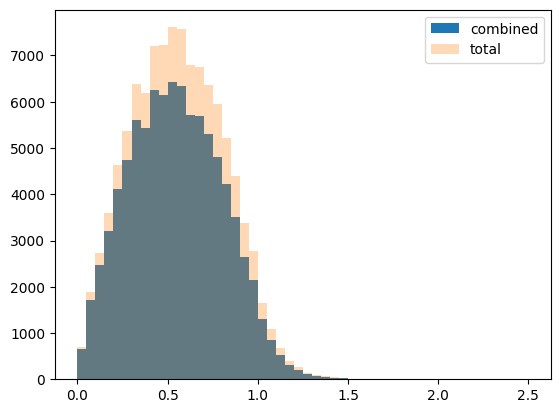

In [55]:
red = merged_specsel_y1["redshift"]
cc = plt.hist(red, bins=50, range=[0, 2.5], label="combined")
red2 = train_y1["redshift"]
cc = plt.hist(red2, bins=50, range=[0, 2.5], label="total", alpha=0.3)
plt.legend()
print(len(red))
# plt.yscale('log')

In [76]:
# let's save this for 10 - year
saveroot = "/pscratch/sd/q/qhang/cnnpz/cardinal/"
fname = saveroot + "train_100k_noisy_y1_i23.SpecSelect.parquet"
merged_specsel_y1.to_parquet(fname)

In [57]:
import h5py

In [58]:
saveroot = "/pscratch/sd/q/qhang/pz_datachllenge_data/"
sim = "cardinal"
Yrs = [1, 10]
train_dataset_taskset2 = {}
train_dataset_taskset2[sim] = {}
for Yr in Yrs:
    fname = saveroot + f"pz_challenge_taskset_2_{sim}_training_{Yr}yr.hdf5"
    with h5py.File(fname, "r") as f:
        data = {key: f[key][:] for key in f.keys()}
    train_dataset_taskset2[sim][Yr] = pd.DataFrame(data)

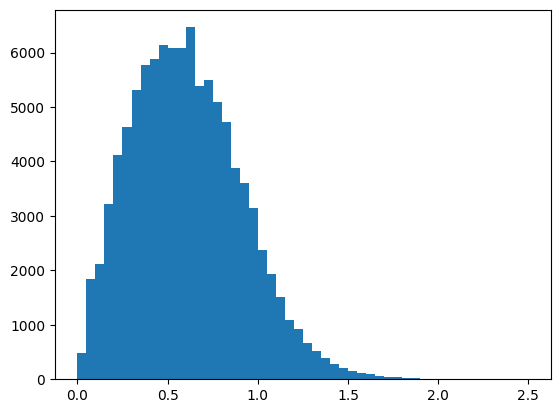

In [59]:
red = train_dataset_taskset2[sim][1]["redshift"]
cc = plt.hist(red, bins=50, range=[0, 2.5], label="combined")

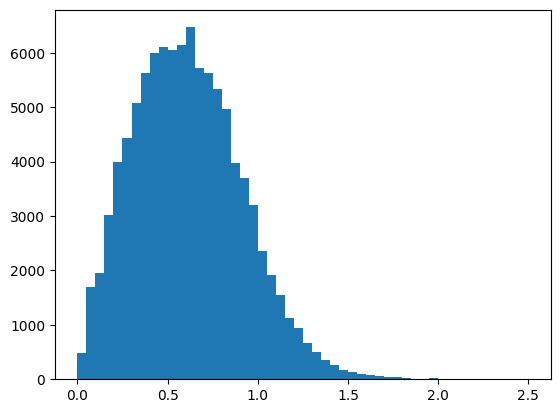

In [60]:
red = train_dataset_taskset2[sim][10]["redshift"]
cc = plt.hist(red, bins=50, range=[0, 2.5], label="combined")

In [ ]:
# to get around 100k, need 4x data: